Cargar archivo y diagnosticar estructura general

In [7]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
#sns.set_style('darkgrid')
plt.style.use('ggplot')

In [3]:
# --- PASO 1: Cargar el archivo y revisar estructura general ---
import pandas as pd

# Ruta local del archivo limpio
ruta=r'C:\Users\Vìctor\OneDrive\Desktop\ESP_Project\df_completo_con_campo.xlsx'

df=pd.read_excel(ruta)

print("✅ Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas\n")

# Revisar los tipos de datos
print("Tipos de datos por columna:")
print(df.dtypes)

# Mostrar las primeras filas
print("\nPrimeras filas:")
display(df.head(50))


✅ Dataset cargado correctamente.
Dimensiones: 16161 filas × 20 columnas

Tipos de datos por columna:
name_                                                    object
date                                             datetime64[ns]
prueba_de_produccion_petróleo_a_24_horas_bbld           float64
prueba_de_producción_agua_a_24_horas_bbld               float64
prueba_pozooil_24__prueba_pozowater_24                  float64
prueba_de_producción_gas_a_24_horas_mcfd                float64
bsw_pct                                                 float64
gravedad_api_del_petroleo                               float64
salinidad_ppm_pu                                        float64
presion_de_intake_psi                                   float64
frecuencia_bomba_hz                                     float64
amperaje_bomba_amp                                      float64
presion_de_tubing_psi                                   float64
presion_de_casing_psi                                   float64
tip

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,presion_de_tubing_psi,presion_de_casing_psi,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,pozo,fecha
0,SCHAO-473HS1UI,2015-01-07,1488.0,470.0,1958.0,0.00,24.00,18.2,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
1,SCHAO-473HS1UI,2015-01-08,1357.0,528.0,1885.0,0.00,28.01,18.2,NaN,NaN,NaN,NaN,110.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
2,SCHAO-473HS1UI,2015-02-01,1436.0,359.0,1795.0,0.00,20.00,18.2,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
3,SCHAO-473HS1UI,2015-02-12,1159.0,597.0,1756.0,0.00,34.00,18.2,NaN,NaN,NaN,NaN,90.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
4,SCHAO-473HS1UI,2015-02-18,1714.0,429.0,2143.0,0.00,20.02,18.2,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
5,SCHAO-473HS1UI,2015-02-23,1737.0,434.0,2171.0,0.00,19.99,18.2,NaN,NaN,NaN,NaN,140.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
6,SCHAO-473HS1UI,2015-02-25,1650.0,521.0,2171.0,0.00,24.00,18.2,NaN,NaN,NaN,NaN,140.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
7,SCHAO-473HS1UI,2015-04-07,1410.0,548.0,1958.0,0.00,27.99,18.2,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
8,SCHAO-473HS1UI,2015-04-15,1525.0,481.0,2006.0,0.00,23.98,18.2,NaN,NaN,NaN,NaN,130.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN
9,SCHAO-473HS1UI,2015-04-21,1547.0,489.0,2036.0,0.00,24.02,18.2,NaN,NaN,NaN,NaN,125.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,SCHAO-473HS1UI,NaN


Verificar porcentaje de nulos por variable

In [5]:
df = df.drop(columns=['fecha'], errors='ignore')

# --- PASO 2: Verificar nulos ---
print("\n🔍 Porcentaje de valores nulos por columna:")
nulos = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(nulos)

# Recomendación: marcar columnas con +40% nulos como "candidatas a imputar con cuidado o eliminar"



🔍 Porcentaje de valores nulos por columna:
presion_de_casing_psi                            68.13
temperatura_de_la_bomba_deg_f                    40.75
presion_de_intake_psi                            32.26
amperaje_bomba_amp                               17.88
frecuencia_bomba_hz                              17.16
salinidad_ppm_pu                                 14.49
etapas_de_la_bomba                               12.51
tipo_de_bomba                                    11.11
gravedad_api_del_petroleo                         0.40
presion_de_tubing_psi                             0.24
bsw_pct                                           0.03
prueba_de_produccion_petróleo_a_24_horas_bbld     0.00
date                                              0.00
name_                                             0.00
prueba_de_producción_gas_a_24_horas_mcfd          0.00
prueba_pozooil_24__prueba_pozowater_24            0.00
prueba_de_producción_agua_a_24_horas_bbld         0.00
campo                

Listado de pozo con mayor numero de datos y valores no nulos

In [9]:
# --- Análisis de cantidad de datos por pozo ---
conteo_por_pozo = df['name_'].value_counts().rename_axis('pozo').reset_index(name='total_registros')
conteo_por_pozo = conteo_por_pozo.sort_values(by='total_registros', ascending=False)

print("Pozos con más datos (top 10):")
display(conteo_por_pozo.head(40))



Pozos con más datos (top 10):


,pozo,total_registros
0,SCH-050UI,670
1,SCH-127HS,648
2,SCH-018UI,636
3,SCH-087BT,626
4,SCH-083HI,599
5,SCH-106HS,596
6,SCH-088T,581
7,SCH-124UI,574
8,SCH-007U,531
9,SCH-134U,530


Ver datos no nulos por pozo y por columna

In [10]:
# --- Conteo de valores no nulos por columna y pozo ---
datos_no_nulos = df.groupby('name_').apply(lambda x: x.notnull().sum())
datos_no_nulos['total_filas'] = df.groupby('name_').size()

# Ordenar por total de filas (más mediciones)
datos_no_nulos = datos_no_nulos.sort_values(by='total_filas', ascending=False)

print("Valores no nulos por pozo (primeras filas):")
display(datos_no_nulos.head(10))


Valores no nulos por pozo (primeras filas):


C:\Users\Vìctor\AppData\Local\Temp\ipykernel_17728\2244488170.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  datos_no_nulos = df.groupby('name_').apply(lambda x: x.notnull().sum())


,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,presion_de_tubing_psi,presion_de_casing_psi,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,pozo,total_filas
name_,,,,,,,,,,,,,,,,,,,,
SCH-050UI,670,670,670,670,670,670,670,669,546,256,547,547,670,82,560,204,547,670,670,670
SCH-127HS,648,648,648,648,648,648,648,647,542,400,542,541,648,37,566,287,542,648,648,648
SCH-018UI,636,636,636,636,636,636,636,636,523,417,523,522,636,123,545,340,523,636,636,636
SCH-087BT,626,626,626,626,626,626,626,626,489,456,489,488,626,203,517,396,489,626,626,626
SCH-083HI,599,599,599,599,599,599,599,598,426,174,427,366,599,0,459,114,427,599,599,599
SCH-106HS,596,596,596,596,596,596,596,595,502,482,503,503,596,1,489,433,503,596,596,596
SCH-088T,581,581,581,581,581,581,581,581,471,390,494,493,580,96,528,335,515,581,581,581
SCH-124UI,574,574,574,574,574,574,574,574,461,297,461,460,574,152,483,241,461,574,574,574
SCH-007U,531,531,531,531,531,531,531,528,417,450,469,468,531,280,494,378,469,531,531,531


Evaluar porcentaje de completitud por pozo: Sumar todos los valores no nulos por pozo

In [ ]:
# Calcular cantidad total de valores no nulos por pozo (en todas las columnas)
df_valores_utiles = df.groupby('name_').apply(lambda x: x.notnull().sum().sum()).reset_index(name='total_datos_validos')

# Ordenar de mayor a menor
df_valores_utiles = df_valores_utiles.sort_values(by='total_datos_validos', ascending=False)

# Mostrar top 10 pozos con más datos útiles
print("Pozos con más datos válidos (todas las columnas):")
display(df_valores_utiles.head(10))


Pozos con más datos válidos (todas las columnas):


C:\Users\Vìctor\AppData\Local\Temp\ipykernel_18840\1753710533.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_valores_utiles = df.groupby('name_').apply(lambda x: x.notnull().sum().sum()).reset_index(name='total_datos_validos')


,name_,total_datos_validos
2,SCH-050UI,9988
9,SCH-127HS,9936
1,SCH-018UI,9876
4,SCH-087BT,9787
6,SCH-106HS,9375
5,SCH-088T,9131
8,SCH-124UI,8756
0,SCH-007U,8732
3,SCH-083HI,8382
12,SCH-142UI,8351


Correlacionar para detectar variable influyente para presion de casing

In [11]:
# Calcular correlación entre presion_de_casing_psi y otras variables para filtrar candidatos
corr_vars = df[['presion_de_casing_psi','presion_de_intake_psi','presion_de_tubing_psi',
                'prueba_de_produccion_petróleo_a_24_horas_bbld',
                'prueba_de_producción_agua_a_24_horas_bbld',
                'bsw_pct','gravedad_api_del_petroleo']].corr()
print(corr_vars['presion_de_casing_psi'].sort_values(ascending=False))


presion_de_casing_psi                            1.000000
presion_de_tubing_psi                            0.213141
gravedad_api_del_petroleo                        0.209515
presion_de_intake_psi                            0.069866
bsw_pct                                         -0.032721
prueba_de_produccion_petróleo_a_24_horas_bbld   -0.037192
prueba_de_producción_agua_a_24_horas_bbld       -0.244793
Name: presion_de_casing_psi, dtype: float64


Encontrar pozos donde la correlación sí es buena:

In [12]:
for pozo in df['name_'].unique():
    df_pozo = df[df['name_'] == pozo]
    corr = df_pozo[['presion_de_casing_psi','presion_de_tubing_psi']].corr().iloc[0,1]
    if corr > 0.5:
        print(f' Pozo {pozo} tiene correlación alta ({round(corr,2)}) → sí se puede imputar localmente')


 Pozo SCH-128HS tiene correlación alta (0.98) → sí se puede imputar localmente
 Pozo SCHA-409HI tiene correlación alta (0.75) → sí se puede imputar localmente
 Pozo SCH-186UI tiene correlación alta (0.9) → sí se puede imputar localmente
 Pozo SCHAM-452HI tiene correlación alta (0.77) → sí se puede imputar localmente
 Pozo SCHAO-471R1TI tiene correlación alta (0.62) → sí se puede imputar localmente
 Pozo SCH-088T tiene correlación alta (0.62) → sí se puede imputar localmente
 Pozo SCHAB-316UI tiene correlación alta (0.52) → sí se puede imputar localmente


Validar pozo con mayor correlacion 

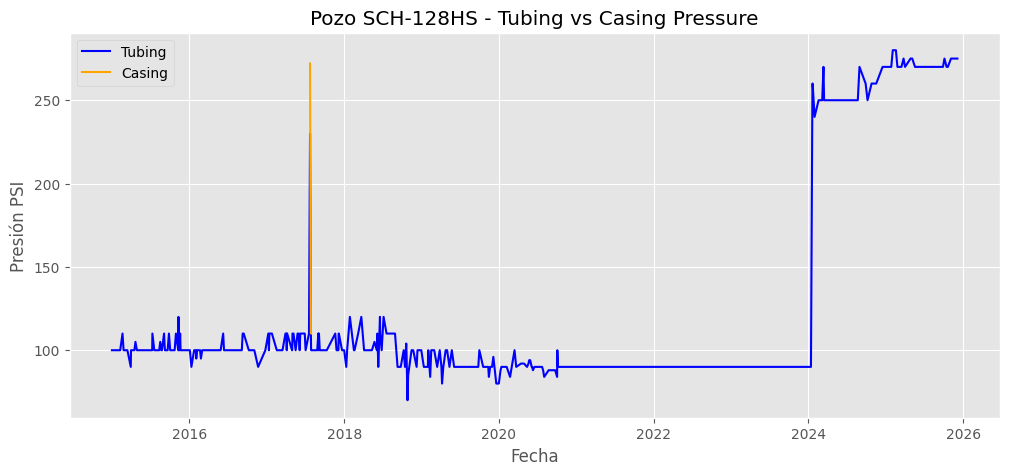

In [13]:
import matplotlib.pyplot as plt
pozo= 'SCH-128HS'

df_pozo = df[df['name_'] == pozo]

plt.figure(figsize=(12, 5))
plt.plot(df_pozo['date'], df_pozo['presion_de_tubing_psi'], label='Tubing', color='blue')
plt.plot(df_pozo['date'], df_pozo['presion_de_casing_psi'], label='Casing', color='orange')
plt.title(f'Pozo {pozo} - Tubing vs Casing Pressure')
plt.xlabel('Fecha')
plt.ylabel('Presión PSI')
plt.legend()
plt.grid(True)
plt.show()


CALCULO DE PRESION DEL CASING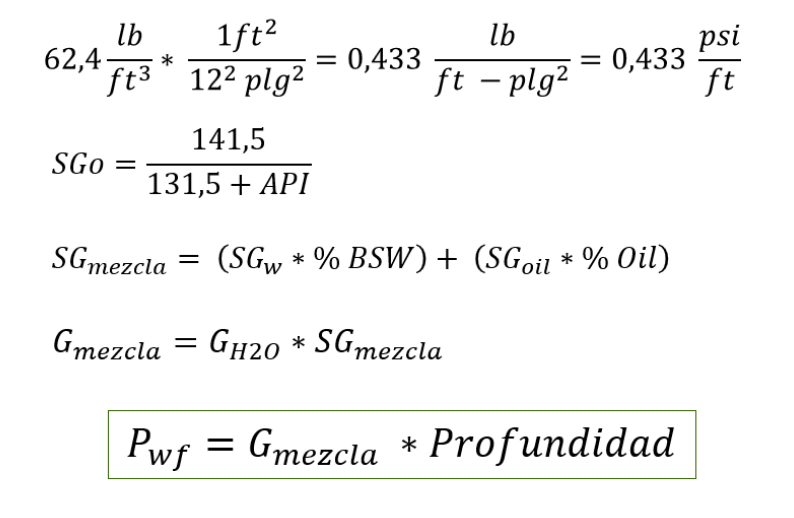

In [ ]:
# Calcular MW del crudo
api = df['gravedad_api_del_petroleo']
mw_crudo = 141.5 / (api + 131.5)
mw_agua = 0.433
bsw = df['bsw_pct'] / 100

# Mezcla corregida por BSW
mw_mixta = (1 - bsw) * mw_crudo + bsw * mw_agua

# TVD promedio
TVD = 7000  # puedes ajustar por pozo si tienes

# Presión hidro estimada
df['presion_casing_hidro'] = 0.052 * mw_mixta * TVD




In [ ]:
df.head()

,name_,date,prueba_de_produccion_petróleo_a_24_horas_bbld,prueba_de_producción_agua_a_24_horas_bbld,prueba_pozooil_24__prueba_pozowater_24,prueba_de_producción_gas_a_24_horas_mcfd,bsw_pct,gravedad_api_del_petroleo,salinidad_ppm_pu,presion_de_intake_psi,frecuencia_bomba_hz,amperaje_bomba_amp,presion_de_tubing_psi,presion_de_casing_psi,tipo_de_bomba,temperatura_de_la_bomba_deg_f,etapas_de_la_bomba,campo,presion_casing_hidro
0,SCHAO-473HS1UI,1969-12-31 19:00:42.011,1488.0,470.0,1958.0,0.0,24.00,18.2,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,989.195507
1,SCHAO-473HS1UI,1969-12-31 19:00:42.012,1357.0,528.0,1885.0,0.0,28.01,18.2,NaN,NaN,NaN,NaN,110.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,1096.986654
2,SCHAO-473HS1UI,1969-12-31 19:00:42.036,1436.0,359.0,1795.0,0.0,20.00,18.2,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,881.673165
3,SCHAO-473HS1UI,1969-12-31 19:00:42.047,1159.0,597.0,1756.0,0.0,34.00,18.2,NaN,NaN,NaN,NaN,90.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,1258.001361
4,SCHAO-473HS1UI,1969-12-31 19:00:42.053,1714.0,429.0,2143.0,0.0,20.02,18.2,NaN,NaN,NaN,NaN,150.0,NaN,NaN,NaN,NaN,SACHA NORTE 1,882.210777


Filtrar pozos con buena cobertura de presion_de_casing_psi

In [ ]:
# Contar cuántos datos reales tiene cada pozo
casing_count = df.groupby('name_')['presion_de_casing_psi'].apply(lambda x: x.notnull().sum())

# Filtrar pozos con al menos 30 mediciones válidas
pozos_con_datos_casing = casing_count[casing_count >= 30].index.tolist()

print("📌 Pozos con buena cobertura de presión de casing:")
print(pozos_con_datos_casing)


📌 Pozos con buena cobertura de presión de casing:
['SCH-007U', 'SCH-018UI', 'SCH-050UI', 'SCH-087BT', 'SCH-088T', 'SCH-124UI', 'SCH-127HS', 'SCH-134U', 'SCH-142UI', 'SCH-186UI', 'SCHA-409HI', 'SCHA-418UI', 'SCHAB-316UI', 'SCHAB-614UI', 'SCHAC-353HI', 'SCHAE-375UI', 'SCHAF-529HUI', 'SCHAF-539HS1UI', 'SCHAH-404HI', 'SCHAJ-428TI', 'SCHAM-452HI', 'SCHAO-471R1TI', 'SCHAO-473HS1UI', 'SCHAO-477HUI', 'SCHAO-478HUI', 'SCHAQ-490UI', 'SCHAQ-492UI', 'SCHAQ-497UI', 'SCHAR-500UI', 'SCHH-237R1HS', 'SCHH-239HS', 'SCHP-181UI', 'SCHP-188UI', 'SCHT-229UI', 'SCHV-226HS', 'SCHV-227HS']


In [ ]:
# Filtrar solo esos pozos con datos reales
df_validacion = df[df['name_'].isin(pozos_con_datos_casing)].copy()

# Eliminar registros donde no hay presión real o estimada
df_validacion = df_validacion.dropna(subset=['presion_de_casing_psi', 'presion_casing_hidro'])

# Comparación directa
print("📊 Comparación estadísticas:")
print(df_validacion[['presion_de_casing_psi', 'presion_casing_hidro']].describe())

# Calcular error absoluto
df_validacion['error_abs'] = abs(df_validacion['presion_de_casing_psi'] - df_validacion['presion_casing_hidro'])

print("\n📈 Error medio absoluto (MAE):", round(df_validacion['error_abs'].mean(), 2), "psi")


📊 Comparación estadísticas:
       presion_de_casing_psi  presion_casing_hidro
count            5033.000000           5033.000000
mean               60.972382           1839.055786
std                50.144008            905.267019
min                 1.000000            342.079137
25%                20.000000            919.402711
50%                50.000000           2329.823875
75%               100.000000           2601.872438
max               370.000000           2978.442576

📈 Error medio absoluto (MAE): 1778.08 psi
